# 第15章: 確率過程の基礎

## 学習目標
- ポアソン過程を理解し適用できる
- 更新過程の基礎を理解する
- ブラウン運動の基本性質を説明できる
- ランダムウォークを理解する

## 📋 学習メタ情報

### 推定学習時間
**120〜150分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 15.1 ポアソン過程

### 定義
計数過程 $\{N(t), t \geq 0\}$ がポアソン過程（強度 $\lambda$）であるとは:

1. $N(0) = 0$
2. 独立増分を持つ
3. $N(t+s) - N(t) \sim \text{Poisson}(\lambda s)$

### 性質
$$P(N(t) = k) = \frac{(\lambda t)^k e^{-\lambda t}}{k!}$$

- $E[N(t)] = \lambda t$
- $\text{Var}(N(t)) = \lambda t$

### 到着間隔時間
$$T_i \sim \text{Exp}(\lambda)$$

到着間隔は指数分布に従い、互いに独立

ポアソン過程のシミュレーション

強度 λ = 5
時間範囲: [0, 10]

イベント数: 52
期待イベント数: 50


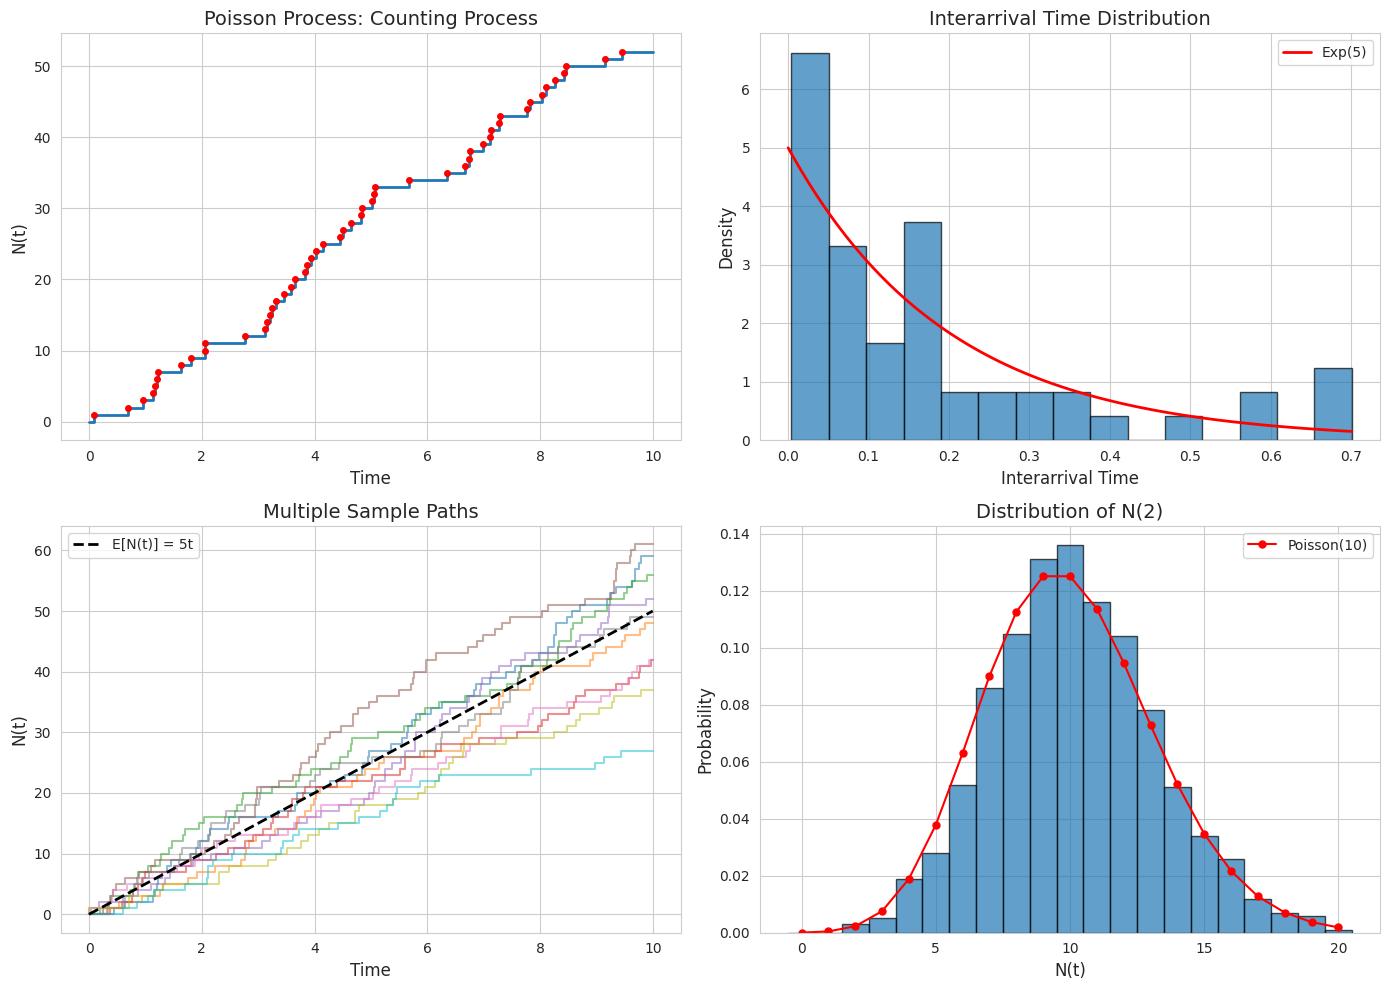

In [2]:
# ポアソン過程のシミュレーション
def simulate_poisson_process(lam, T):
    """Simulate a Poisson process with rate lambda up to time T."""
    arrivals = []
    t = 0
    
    while True:
        # Interarrival time is exponential
        interarrival = np.random.exponential(1/lam)
        t += interarrival
        if t > T:
            break
        arrivals.append(t)
    
    return np.array(arrivals)

# Parameters
lam = 5  # Rate (events per unit time)
T = 10   # Time horizon

# Simulate
arrivals = simulate_poisson_process(lam, T)

print("ポアソン過程のシミュレーション")
print("="*50)
print(f"\n強度 λ = {lam}")
print(f"時間範囲: [0, {T}]")
print(f"\nイベント数: {len(arrivals)}")
print(f"期待イベント数: {lam * T}")

# Create counting process
times = np.concatenate([[0], arrivals, [T]])
counts = np.concatenate([[0], np.arange(1, len(arrivals)+1), [len(arrivals)]])

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Counting process
axes[0, 0].step(times, counts, where='post', linewidth=2)
axes[0, 0].plot(arrivals, np.arange(1, len(arrivals)+1), 'ro', markersize=4)
axes[0, 0].set_xlabel('Time', fontsize=12)
axes[0, 0].set_ylabel('N(t)', fontsize=12)
axes[0, 0].set_title('Poisson Process: Counting Process', fontsize=14)

# Interarrival times
interarrivals = np.diff(np.concatenate([[0], arrivals]))
axes[0, 1].hist(interarrivals, bins=15, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(0, max(interarrivals), 100)
axes[0, 1].plot(x, lam * np.exp(-lam * x), 'r-', linewidth=2, 
                label=f'Exp({lam})')
axes[0, 1].set_xlabel('Interarrival Time', fontsize=12)
axes[0, 1].set_ylabel('Density', fontsize=12)
axes[0, 1].set_title('Interarrival Time Distribution', fontsize=14)
axes[0, 1].legend()

# Multiple sample paths
for _ in range(10):
    arr = simulate_poisson_process(lam, T)
    t = np.concatenate([[0], arr, [T]])
    c = np.concatenate([[0], np.arange(1, len(arr)+1), [len(arr)]])
    axes[1, 0].step(t, c, where='post', alpha=0.5)

axes[1, 0].plot([0, T], [0, lam*T], 'k--', linewidth=2, label=f'E[N(t)] = {lam}t')
axes[1, 0].set_xlabel('Time', fontsize=12)
axes[1, 0].set_ylabel('N(t)', fontsize=12)
axes[1, 0].set_title('Multiple Sample Paths', fontsize=14)
axes[1, 0].legend()

# Distribution of N(t) at t=2
n_simulations = 1000
t_test = 2
Nt_samples = []
for _ in range(n_simulations):
    arr = simulate_poisson_process(lam, t_test)
    Nt_samples.append(len(arr))

axes[1, 1].hist(Nt_samples, bins=range(max(Nt_samples)+2), density=True, 
                alpha=0.7, edgecolor='black', align='left')
k_values = np.arange(0, max(Nt_samples)+1)
poisson_pmf = stats.poisson.pmf(k_values, lam * t_test)
axes[1, 1].plot(k_values, poisson_pmf, 'ro-', markersize=5, 
                label=f'Poisson({lam * t_test})')
axes[1, 1].set_xlabel('N(t)', fontsize=12)
axes[1, 1].set_ylabel('Probability', fontsize=12)
axes[1, 1].set_title(f'Distribution of N({t_test})', fontsize=14)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

ポアソン過程の合成

過程1 (λ1=3): 37 イベント
過程2 (λ2=2): 19 イベント
合成過程 (λ=5): 56 イベント
期待値: 50

ポアソン過程の分解
元の過程 (λ=5): 55 イベント
タイプA (λ=2.0): 18 イベント (期待: 20.0)
タイプB (λ=3.0): 37 イベント (期待: 30.0)


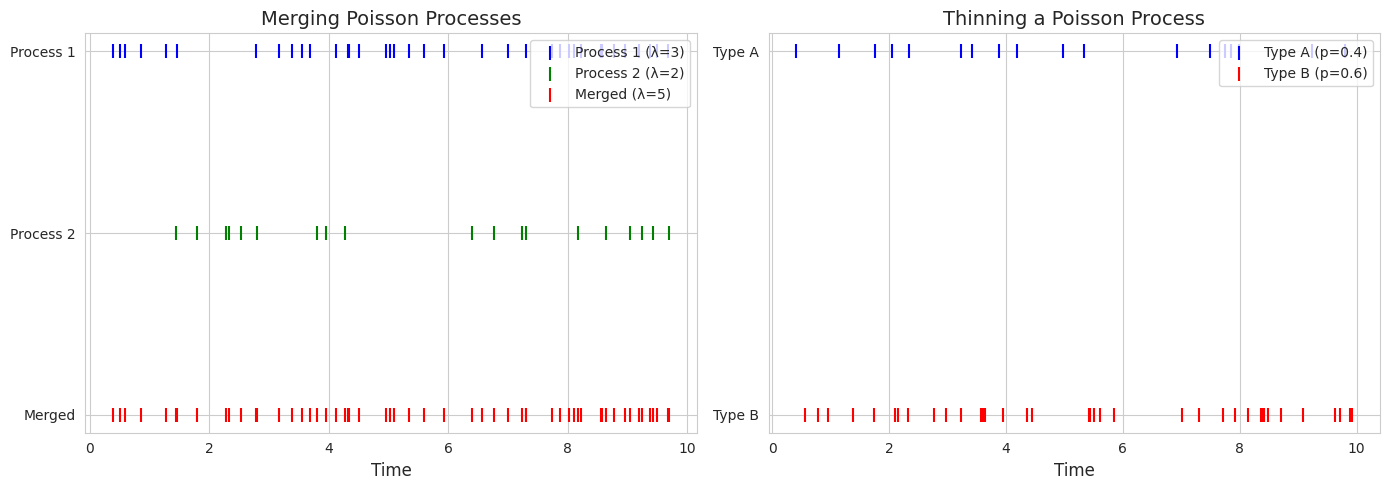

In [3]:
# ポアソン過程の合成と分解
np.random.seed(123)

# Merging: two independent Poisson processes
lam1, lam2 = 3, 2
T = 10

arrivals1 = simulate_poisson_process(lam1, T)
arrivals2 = simulate_poisson_process(lam2, T)
arrivals_merged = np.sort(np.concatenate([arrivals1, arrivals2]))

print("ポアソン過程の合成")
print("="*50)
print(f"\n過程1 (λ1={lam1}): {len(arrivals1)} イベント")
print(f"過程2 (λ2={lam2}): {len(arrivals2)} イベント")
print(f"合成過程 (λ={lam1+lam2}): {len(arrivals_merged)} イベント")
print(f"期待値: {(lam1+lam2)*T}")

# Thinning: split a Poisson process
lam_total = 5
p = 0.4  # Probability of type A

arrivals_total = simulate_poisson_process(lam_total, T)
types = np.random.random(len(arrivals_total)) < p
arrivals_A = arrivals_total[types]
arrivals_B = arrivals_total[~types]

print(f"\nポアソン過程の分解")
print(f"元の過程 (λ={lam_total}): {len(arrivals_total)} イベント")
print(f"タイプA (λ={lam_total*p}): {len(arrivals_A)} イベント (期待: {lam_total*p*T})")
print(f"タイプB (λ={lam_total*(1-p)}): {len(arrivals_B)} イベント (期待: {lam_total*(1-p)*T})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Merging
for i, (arr, label, color) in enumerate([
    (arrivals1, f'Process 1 (λ={lam1})', 'blue'),
    (arrivals2, f'Process 2 (λ={lam2})', 'green'),
    (arrivals_merged, f'Merged (λ={lam1+lam2})', 'red')
]):
    y = 3 - i
    axes[0].scatter(arr, [y]*len(arr), marker='|', s=100, color=color, label=label)

axes[0].set_yticks([1, 2, 3])
axes[0].set_yticklabels(['Merged', 'Process 2', 'Process 1'])
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_title('Merging Poisson Processes', fontsize=14)
axes[0].legend(loc='upper right')

# Thinning
axes[1].scatter(arrivals_A, [2]*len(arrivals_A), marker='|', s=100, 
                color='blue', label=f'Type A (p={p})')
axes[1].scatter(arrivals_B, [1]*len(arrivals_B), marker='|', s=100, 
                color='red', label=f'Type B (p={1-p})')
axes[1].set_yticks([1, 2])
axes[1].set_yticklabels(['Type B', 'Type A'])
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_title('Thinning a Poisson Process', fontsize=14)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 15.2 更新過程

### 定義
更新過程は、到着間隔時間 $\{X_i\}$ が独立同一分布に従う計数過程:
$$N(t) = \max\{n : S_n \leq t\}$$
ここで $S_n = X_1 + X_2 + \cdots + X_n$

### 更新関数
$$m(t) = E[N(t)]$$

### 基本更新定理
$$\lim_{t \to \infty} \frac{N(t)}{t} = \frac{1}{\mu} \quad \text{(確率1で)}$$
ここで $\mu = E[X_i]$

更新過程の比較

平均到着間隔: 1.0
時間範囲: [0, 50]

分布                          イベント数          期待値
--------------------------------------------------
Exponential                    57         50.0
Gamma(2,0.5)                   50         50.0
Uniform(0,2)                   52         50.0


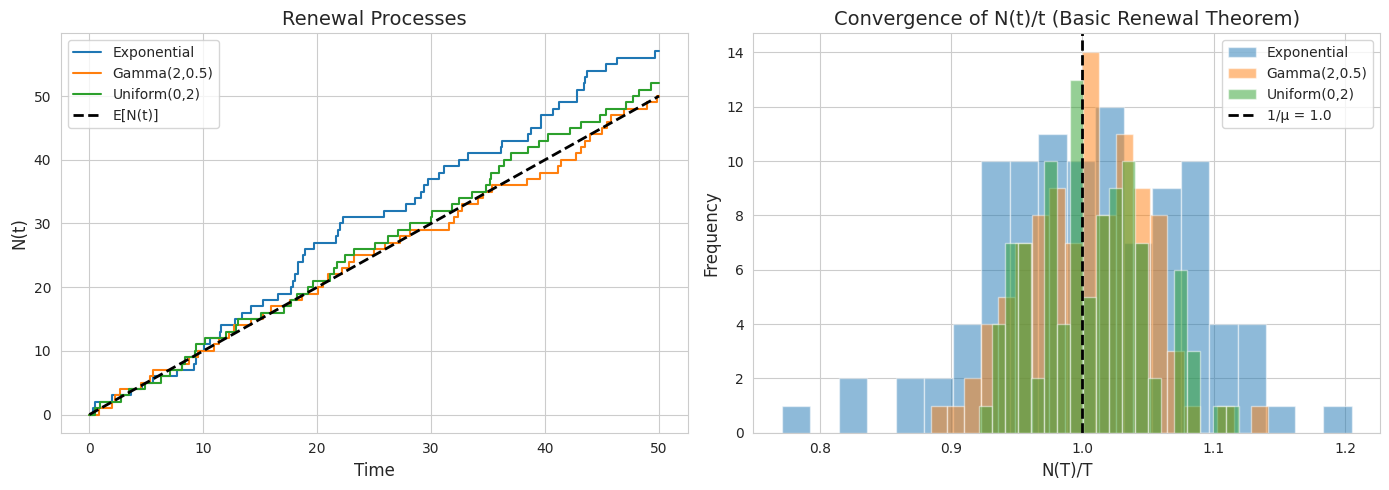

In [4]:
# 更新過程のシミュレーション
def simulate_renewal_process(dist, T, **params):
    """Simulate a renewal process with given interarrival distribution."""
    arrivals = []
    t = 0
    
    while True:
        if dist == 'exponential':
            interarrival = np.random.exponential(params['scale'])
        elif dist == 'gamma':
            interarrival = np.random.gamma(params['shape'], params['scale'])
        elif dist == 'uniform':
            interarrival = np.random.uniform(params['low'], params['high'])
        
        t += interarrival
        if t > T:
            break
        arrivals.append(t)
    
    return np.array(arrivals)

# Compare different interarrival distributions
T = 50
mean_interarrival = 1.0  # Same mean for all

np.random.seed(456)

distributions = [
    ('Exponential', 'exponential', {'scale': mean_interarrival}),
    ('Gamma(2,0.5)', 'gamma', {'shape': 2, 'scale': mean_interarrival/2}),
    ('Uniform(0,2)', 'uniform', {'low': 0, 'high': 2*mean_interarrival})
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

print("更新過程の比較")
print("="*50)
print(f"\n平均到着間隔: {mean_interarrival}")
print(f"時間範囲: [0, {T}]")
print(f"\n{'分布':<20} {'イベント数':>12} {'期待値':>12}")
print("-"*50)

for name, dist, params in distributions:
    arrivals = simulate_renewal_process(dist, T, **params)
    n_events = len(arrivals)
    expected = T / mean_interarrival
    
    print(f"{name:<20} {n_events:>12} {expected:>12.1f}")
    
    # Plot counting process
    times = np.concatenate([[0], arrivals, [T]])
    counts = np.concatenate([[0], np.arange(1, len(arrivals)+1), [len(arrivals)]])
    axes[0].step(times, counts, where='post', label=name, linewidth=1.5)

axes[0].plot([0, T], [0, T/mean_interarrival], 'k--', linewidth=2, label='E[N(t)]')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('N(t)', fontsize=12)
axes[0].set_title('Renewal Processes', fontsize=14)
axes[0].legend()

# N(t)/t convergence
n_simulations = 100
T_long = 200

for name, dist, params in distributions:
    ratios = []
    for _ in range(n_simulations):
        arrivals = simulate_renewal_process(dist, T_long, **params)
        times = np.concatenate([[1], arrivals[arrivals >= 1]])
        ratio = len(arrivals[arrivals <= times[-1]]) / times[-1]
        ratios.append(ratio)
    
    axes[1].hist(ratios, bins=20, alpha=0.5, label=name)

axes[1].axvline(1/mean_interarrival, color='black', linestyle='--', 
                linewidth=2, label=f'1/μ = {1/mean_interarrival}')
axes[1].set_xlabel('N(T)/T', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Convergence of N(t)/t (Basic Renewal Theorem)', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 15.3 ブラウン運動

### 定義
標準ブラウン運動（ウィーナー過程）$\{W(t), t \geq 0\}$ は:

1. $W(0) = 0$
2. 独立増分を持つ
3. $W(t) - W(s) \sim N(0, t-s)$ for $t > s$
4. サンプルパスはほとんど確実に連続

### 性質
- $E[W(t)] = 0$
- $\text{Var}(W(t)) = t$
- $\text{Cov}(W(s), W(t)) = \min(s, t)$

### 一般化ブラウン運動
$$X(t) = \mu t + \sigma W(t)$$
- $E[X(t)] = \mu t$ (ドリフト)
- $\text{Var}(X(t)) = \sigma^2 t$

標準ブラウン運動

時間範囲: [0, 1]
ステップ数: 1000

W(1) = 0.6320
理論分散 = 1


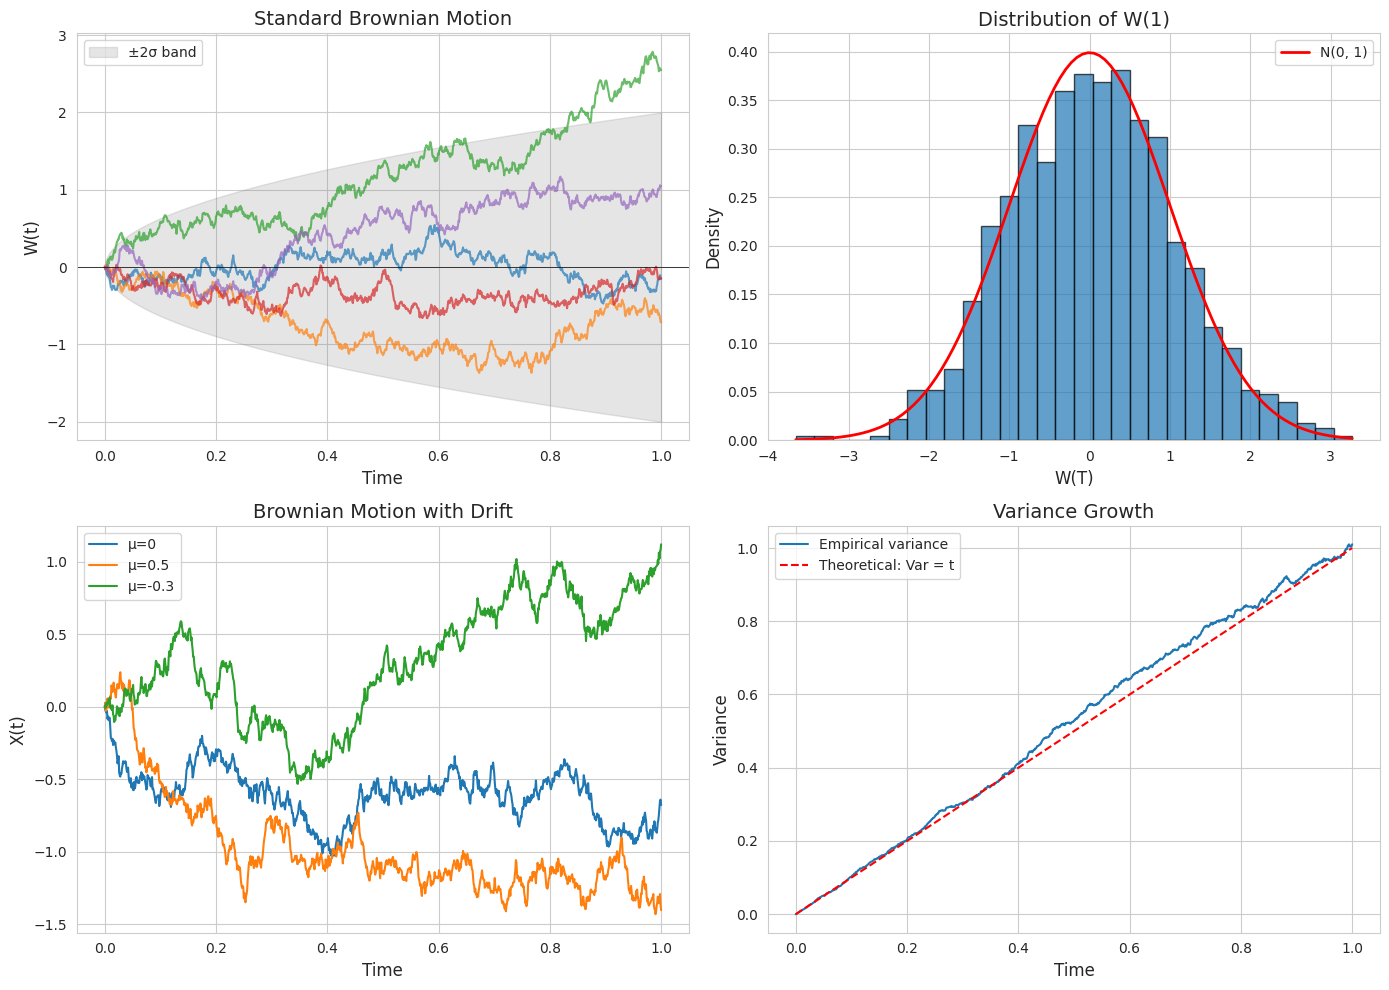

In [5]:
# ブラウン運動のシミュレーション
def simulate_brownian_motion(T, n_steps, mu=0, sigma=1):
    """Simulate Brownian motion with drift mu and volatility sigma."""
    dt = T / n_steps
    dW = np.random.normal(0, np.sqrt(dt), n_steps)
    W = np.cumsum(dW)
    W = np.concatenate([[0], W])
    
    t = np.linspace(0, T, n_steps + 1)
    X = mu * t + sigma * W
    
    return t, X, W

# Parameters
T = 1
n_steps = 1000

np.random.seed(789)

# Simulate standard Brownian motion
t, X, W = simulate_brownian_motion(T, n_steps)

print("標準ブラウン運動")
print("="*50)
print(f"\n時間範囲: [0, {T}]")
print(f"ステップ数: {n_steps}")
print(f"\nW({T}) = {W[-1]:.4f}")
print(f"理論分散 = {T}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sample paths
for _ in range(5):
    t, X, W = simulate_brownian_motion(T, n_steps)
    axes[0, 0].plot(t, W, alpha=0.7)

axes[0, 0].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0, 0].fill_between(t, -2*np.sqrt(t), 2*np.sqrt(t), alpha=0.2, color='gray',
                        label='±2σ band')
axes[0, 0].set_xlabel('Time', fontsize=12)
axes[0, 0].set_ylabel('W(t)', fontsize=12)
axes[0, 0].set_title('Standard Brownian Motion', fontsize=14)
axes[0, 0].legend()

# Distribution of W(T)
n_simulations = 1000
WT_samples = []
for _ in range(n_simulations):
    _, _, W = simulate_brownian_motion(T, n_steps)
    WT_samples.append(W[-1])

axes[0, 1].hist(WT_samples, bins=30, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(min(WT_samples), max(WT_samples), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, 0, np.sqrt(T)), 'r-', linewidth=2,
                label=f'N(0, {T})')
axes[0, 1].set_xlabel('W(T)', fontsize=12)
axes[0, 1].set_ylabel('Density', fontsize=12)
axes[0, 1].set_title(f'Distribution of W({T})', fontsize=14)
axes[0, 1].legend()

# Brownian motion with drift
for mu, label in [(0, 'μ=0'), (0.5, 'μ=0.5'), (-0.3, 'μ=-0.3')]:
    t, X, _ = simulate_brownian_motion(T, n_steps, mu=mu, sigma=1)
    axes[1, 0].plot(t, X, label=label)

axes[1, 0].set_xlabel('Time', fontsize=12)
axes[1, 0].set_ylabel('X(t)', fontsize=12)
axes[1, 0].set_title('Brownian Motion with Drift', fontsize=14)
axes[1, 0].legend()

# Variance growth
n_paths = 500
paths = np.zeros((n_paths, n_steps + 1))
for i in range(n_paths):
    _, _, paths[i] = simulate_brownian_motion(T, n_steps)

variance = np.var(paths, axis=0)
axes[1, 1].plot(t, variance, label='Empirical variance')
axes[1, 1].plot(t, t, 'r--', label='Theoretical: Var = t')
axes[1, 1].set_xlabel('Time', fontsize=12)
axes[1, 1].set_ylabel('Variance', fontsize=12)
axes[1, 1].set_title('Variance Growth', fontsize=14)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

ブラウン運動の共分散構造

Cov(W(s), W(t)) = min(s, t)

     s      t        理論値        実測値
----------------------------------------
  0.20   0.50     0.2000     0.1873
  0.40   0.50     0.4000     0.3795
  0.60   0.50     0.5000     0.4729
  0.80   0.50     0.5000     0.4761


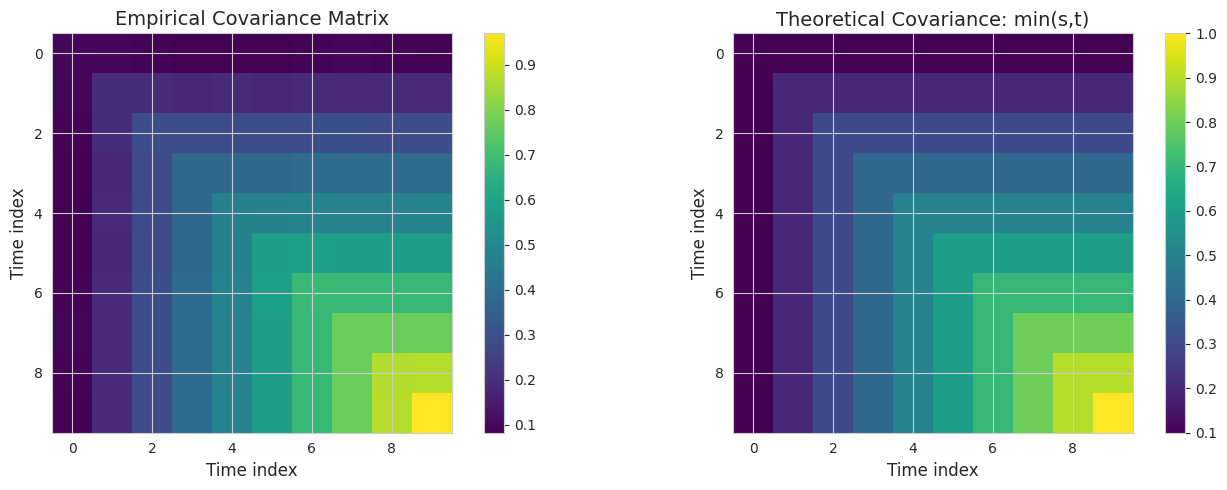

In [6]:
# ブラウン運動の性質
np.random.seed(111)

# Covariance structure
n_simulations = 1000
T = 1
n_steps = 100

# Test covariance at different times
s_values = [0.2, 0.4, 0.6, 0.8]
t_test = 0.5

paths = np.zeros((n_simulations, n_steps + 1))
for i in range(n_simulations):
    t_arr, _, paths[i] = simulate_brownian_motion(T, n_steps)

print("ブラウン運動の共分散構造")
print("="*50)
print(f"\nCov(W(s), W(t)) = min(s, t)")
print(f"\n{'s':>6} {'t':>6} {'理論値':>10} {'実測値':>10}")
print("-"*40)

t_idx = int(t_test * n_steps)
for s in s_values:
    s_idx = int(s * n_steps)
    cov_empirical = np.cov(paths[:, s_idx], paths[:, t_idx])[0, 1]
    cov_theoretical = min(s, t_test)
    print(f"{s:>6.2f} {t_test:>6.2f} {cov_theoretical:>10.4f} {cov_empirical:>10.4f}")

# Visualize covariance matrix
n_times = 10
time_points = np.linspace(0, T, n_times + 1)[1:]
indices = [int(tp * n_steps) for tp in time_points]

cov_matrix = np.cov(paths[:, indices].T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Empirical covariance
im = axes[0].imshow(cov_matrix, cmap='viridis')
axes[0].set_xlabel('Time index', fontsize=12)
axes[0].set_ylabel('Time index', fontsize=12)
axes[0].set_title('Empirical Covariance Matrix', fontsize=14)
plt.colorbar(im, ax=axes[0])

# Theoretical covariance
cov_theoretical = np.minimum.outer(time_points, time_points)
im = axes[1].imshow(cov_theoretical, cmap='viridis')
axes[1].set_xlabel('Time index', fontsize=12)
axes[1].set_ylabel('Time index', fontsize=12)
axes[1].set_title('Theoretical Covariance: min(s,t)', fontsize=14)
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

## 15.4 ランダムウォーク

### 単純ランダムウォーク
$$S_n = X_1 + X_2 + \cdots + X_n$$
ここで $P(X_i = 1) = p$, $P(X_i = -1) = 1-p$

### 性質
- $E[S_n] = n(2p-1)$
- $\text{Var}(S_n) = 4np(1-p)$

### ブラウン運動との関係
適切にスケールした対称ランダムウォークは、ブラウン運動に収束:
$$\frac{S_{\lfloor nt \rfloor}}{\sqrt{n}} \xrightarrow{d} W(t)$$

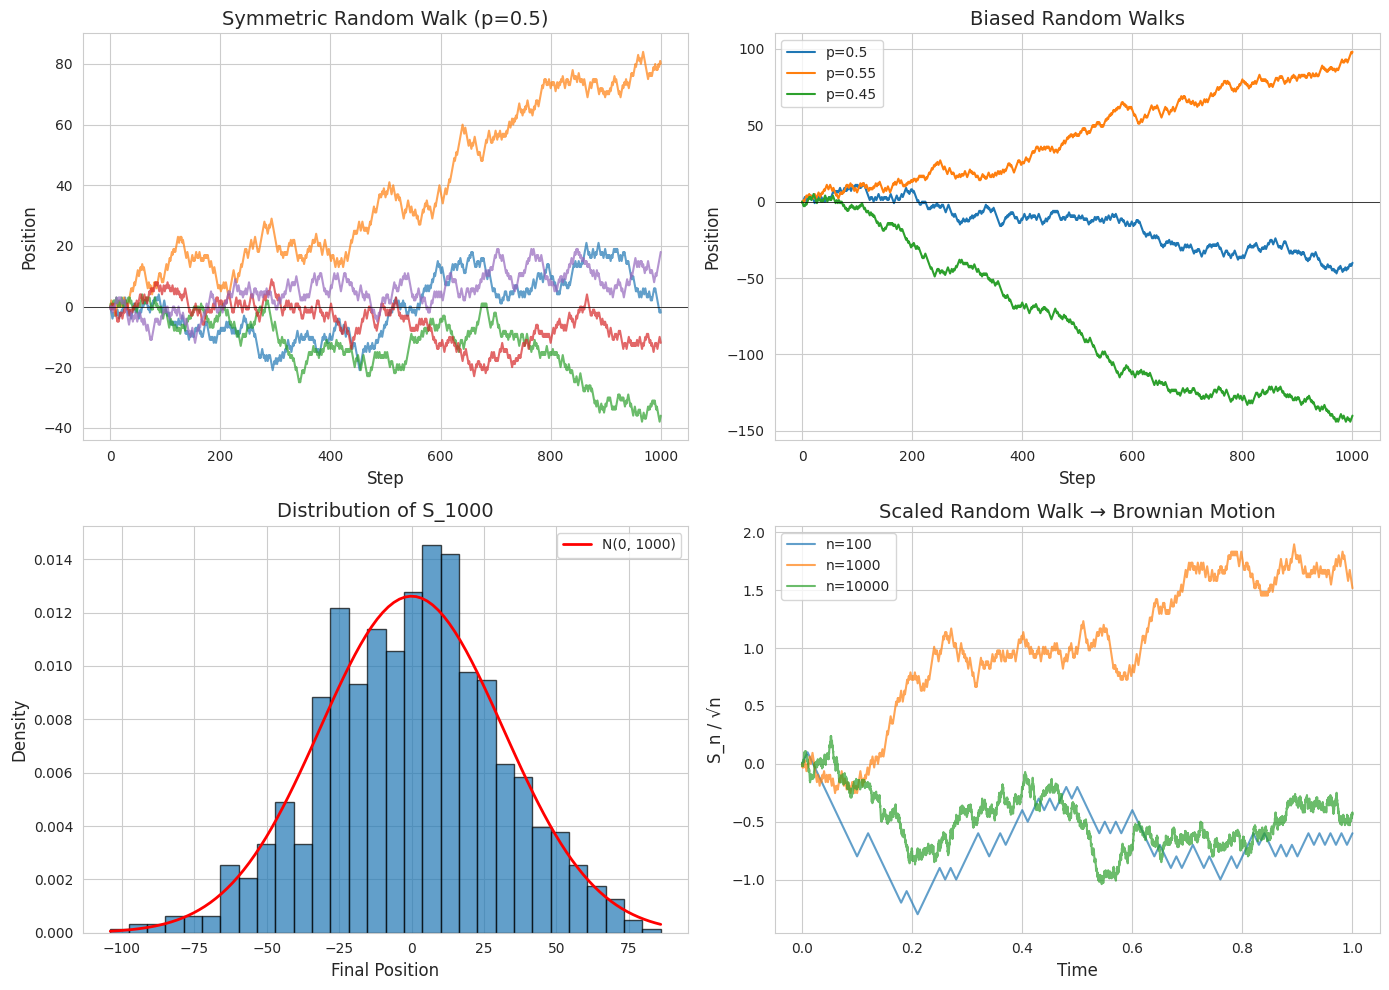

In [7]:
# ランダムウォークのシミュレーション
def simulate_random_walk(n_steps, p=0.5):
    """Simulate a simple random walk."""
    steps = np.random.choice([1, -1], n_steps, p=[p, 1-p])
    walk = np.cumsum(steps)
    return np.concatenate([[0], walk])

np.random.seed(222)

n_steps = 1000

# Different probabilities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Symmetric random walk
for _ in range(5):
    walk = simulate_random_walk(n_steps, p=0.5)
    axes[0, 0].plot(walk, alpha=0.7)

axes[0, 0].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0, 0].set_xlabel('Step', fontsize=12)
axes[0, 0].set_ylabel('Position', fontsize=12)
axes[0, 0].set_title('Symmetric Random Walk (p=0.5)', fontsize=14)

# Biased random walks
for p in [0.5, 0.55, 0.45]:
    walk = simulate_random_walk(n_steps, p=p)
    axes[0, 1].plot(walk, label=f'p={p}')

axes[0, 1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].set_xlabel('Step', fontsize=12)
axes[0, 1].set_ylabel('Position', fontsize=12)
axes[0, 1].set_title('Biased Random Walks', fontsize=14)
axes[0, 1].legend()

# Distribution of final position
n_simulations = 1000
final_positions = [simulate_random_walk(n_steps, p=0.5)[-1] 
                   for _ in range(n_simulations)]

axes[1, 0].hist(final_positions, bins=30, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(min(final_positions), max(final_positions), 100)
theoretical_std = np.sqrt(n_steps)  # σ = sqrt(n) for p=0.5
axes[1, 0].plot(x, stats.norm.pdf(x, 0, theoretical_std), 'r-', linewidth=2,
                label=f'N(0, {n_steps})')
axes[1, 0].set_xlabel('Final Position', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)
axes[1, 0].set_title(f'Distribution of S_{n_steps}', fontsize=14)
axes[1, 0].legend()

# Convergence to Brownian motion
T = 1
for n in [100, 1000, 10000]:
    walk = simulate_random_walk(n)
    scaled_walk = walk / np.sqrt(n)
    t = np.linspace(0, T, n+1)
    axes[1, 1].plot(t, scaled_walk, label=f'n={n}', alpha=0.7)

axes[1, 1].set_xlabel('Time', fontsize=12)
axes[1, 1].set_ylabel('S_n / √n', fontsize=12)
axes[1, 1].set_title('Scaled Random Walk → Brownian Motion', fontsize=14)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

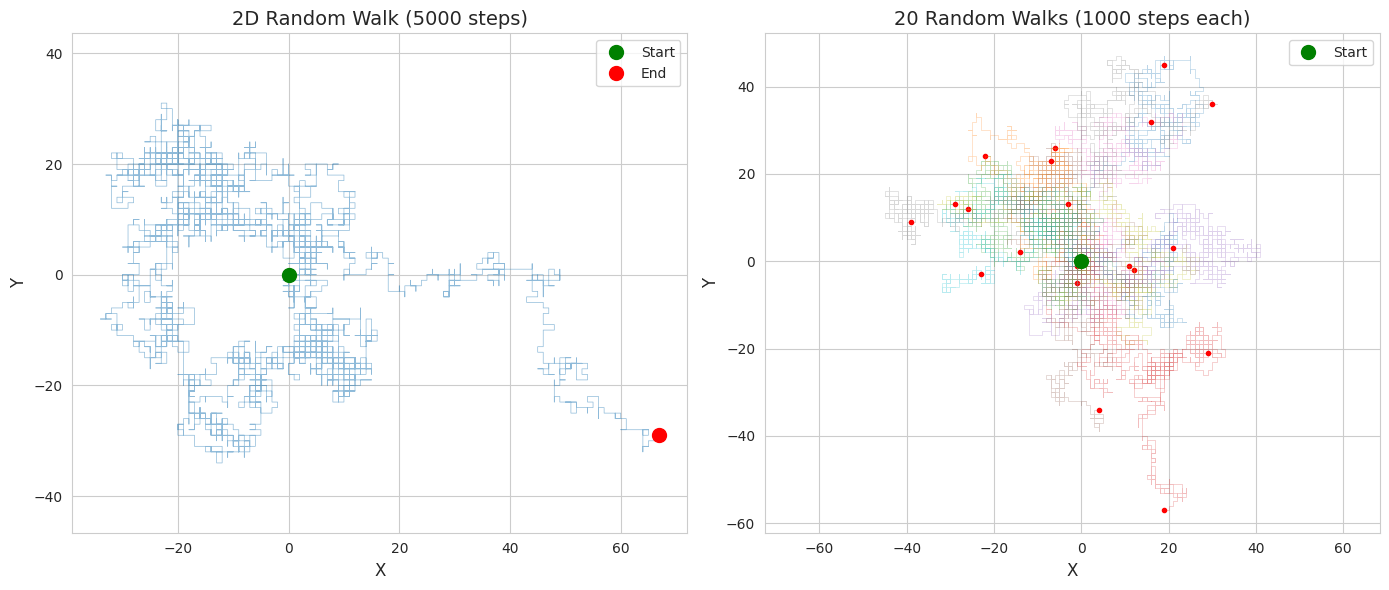

In [8]:
# 2次元ランダムウォーク
def simulate_2d_random_walk(n_steps):
    """Simulate a 2D random walk."""
    angles = np.random.choice([0, np.pi/2, np.pi, 3*np.pi/2], n_steps)
    dx = np.cos(angles)
    dy = np.sin(angles)
    x = np.cumsum(np.concatenate([[0], dx]))
    y = np.cumsum(np.concatenate([[0], dy]))
    return x, y

np.random.seed(333)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Single long walk
n_steps = 5000
x, y = simulate_2d_random_walk(n_steps)

axes[0].plot(x, y, alpha=0.5, linewidth=0.5)
axes[0].plot(x[0], y[0], 'go', markersize=10, label='Start')
axes[0].plot(x[-1], y[-1], 'ro', markersize=10, label='End')
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('Y', fontsize=12)
axes[0].set_title(f'2D Random Walk ({n_steps} steps)', fontsize=14)
axes[0].legend()
axes[0].axis('equal')

# Multiple walks
n_walks = 20
n_steps = 1000

for _ in range(n_walks):
    x, y = simulate_2d_random_walk(n_steps)
    axes[1].plot(x, y, alpha=0.3, linewidth=0.5)
    axes[1].plot(x[-1], y[-1], 'ro', markersize=3)

axes[1].plot(0, 0, 'go', markersize=10, label='Start')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('Y', fontsize=12)
axes[1].set_title(f'{n_walks} Random Walks ({n_steps} steps each)', fontsize=14)
axes[1].legend()
axes[1].axis('equal')

plt.tight_layout()
plt.show()

## 15.5 練習問題

### 問題1
強度 λ=3 のポアソン過程について、時間区間 [0, 5] に:
(a) ちょうど10個のイベントが起こる確率
(b) 少なくとも15個のイベントが起こる確率
を求めよ。

### 問題2
標準ブラウン運動について:
(a) W(3) の分布を答えよ
(b) P(W(4) > 2) を計算せよ
(c) Cov(W(2), W(5)) を求めよ

### 問題3
対称ランダムウォーク（p=0.5）について、100ステップ後の位置が20以上になる確率を求めよ。

In [9]:
# 問題1の解答
print("問題1: ポアソン過程")
print("="*50)

lam = 3
T = 5
mean = lam * T  # = 15

# (a) P(N(5) = 10)
prob_a = stats.poisson.pmf(10, mean)
print(f"\n(a) P(N(5) = 10) = {prob_a:.6f}")

# (b) P(N(5) >= 15)
prob_b = 1 - stats.poisson.cdf(14, mean)
print(f"(b) P(N(5) >= 15) = {prob_b:.6f}")

# Verify with simulation
np.random.seed(444)
n_simulations = 10000

counts = [len(simulate_poisson_process(lam, T)) for _ in range(n_simulations)]
sim_a = sum(1 for c in counts if c == 10) / n_simulations
sim_b = sum(1 for c in counts if c >= 15) / n_simulations

print(f"\nシミュレーション検証:")
print(f"(a) {sim_a:.6f}")
print(f"(b) {sim_b:.6f}")

問題1: ポアソン過程

(a) P(N(5) = 10) = 0.048611
(b) P(N(5) >= 15) = 0.534346

シミュレーション検証:
(a) 0.052000
(b) 0.527900


In [10]:
# 問題2の解答
print("問題2: 標準ブラウン運動")
print("="*50)

# (a) Distribution of W(3)
print(f"\n(a) W(3) ~ N(0, 3)")

# (b) P(W(4) > 2)
prob_b = 1 - stats.norm.cdf(2, 0, np.sqrt(4))
print(f"(b) P(W(4) > 2) = {prob_b:.6f}")

# (c) Cov(W(2), W(5))
cov_c = min(2, 5)
print(f"(c) Cov(W(2), W(5)) = min(2, 5) = {cov_c}")

# Verify with simulation
np.random.seed(555)
n_simulations = 10000
n_steps = 5000

W3_samples = []
W4_samples = []
W2_samples = []
W5_samples = []

for _ in range(n_simulations):
    _, _, W = simulate_brownian_motion(5, n_steps)
    W2_samples.append(W[int(2*n_steps/5)])
    W3_samples.append(W[int(3*n_steps/5)])
    W4_samples.append(W[int(4*n_steps/5)])
    W5_samples.append(W[-1])

print(f"\nシミュレーション検証:")
print(f"(a) W(3): mean={np.mean(W3_samples):.4f}, var={np.var(W3_samples):.4f}")
print(f"(b) P(W(4) > 2) = {np.mean(np.array(W4_samples) > 2):.6f}")
print(f"(c) Cov(W(2), W(5)) = {np.cov(W2_samples, W5_samples)[0,1]:.4f}")

問題2: 標準ブラウン運動

(a) W(3) ~ N(0, 3)
(b) P(W(4) > 2) = 0.158655
(c) Cov(W(2), W(5)) = min(2, 5) = 2



シミュレーション検証:
(a) W(3): mean=0.0202, var=3.0588
(b) P(W(4) > 2) = 0.161900
(c) Cov(W(2), W(5)) = 2.0764


In [11]:
# 問題3の解答
print("問題3: ランダムウォーク")
print("="*50)

n = 100
p = 0.5

# S_n ~ approximately N(0, n) for p=0.5
# More precisely, S_n = 2*X - n where X ~ Binomial(n, p)
# P(S_n >= 20) = P(X >= 60) where X ~ Binomial(100, 0.5)

# Using normal approximation
mean = n * (2*p - 1)  # = 0
var = 4 * n * p * (1-p)  # = 100
std = np.sqrt(var)  # = 10

# Continuity correction
prob = 1 - stats.norm.cdf(19.5, mean, std)
print(f"\n正規近似 (連続性補正): P(S_100 >= 20) = {prob:.6f}")

# Exact calculation using binomial
# S_n >= 20 means number of +1's minus number of -1's >= 20
# Let X = number of +1's, then X - (n-X) >= 20, so X >= 60
prob_exact = 1 - stats.binom.cdf(59, n, p)
print(f"二項分布による厳密値: P(S_100 >= 20) = {prob_exact:.6f}")

# Verify with simulation
np.random.seed(666)
n_simulations = 10000
final_positions = [simulate_random_walk(n, p=0.5)[-1] for _ in range(n_simulations)]
sim_prob = np.mean(np.array(final_positions) >= 20)
print(f"シミュレーション: P(S_100 >= 20) = {sim_prob:.6f}")

問題3: ランダムウォーク

正規近似 (連続性補正): P(S_100 >= 20) = 0.025588
二項分布による厳密値: P(S_100 >= 20) = 0.028444


シミュレーション: P(S_100 >= 20) = 0.031000


## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---